# New England — Data Preparation

Builds the training corpus for the New England Faraday model from four public sources:

| Source | Role |
|---|---|
| NREL End-Use Load Profiles (`resstock_amy2018_release_2`, upgrade 0) | 15-min residential load timeseries (weather year 2018) |
| EIA RECS 2020 microdata | Stratification targets, DER shares, annual-kWh validation reference |
| NOAA GHCN-Daily | Daily mean temperature → `temp_bin` conditioning label |
| ISO-NE hourly demand (EIA API, 2019) | Peak-timing validation reference |

The pipeline is driven by two CLI commands (run from the repo root):

```
pipenv run python app/app.py get-ne-data --timeseries   # ~13 GB download
pipenv run python scripts/fetch_pv_shapes.py             # PV shapes (Open-Meteo)
pipenv run python app/app.py preprocess-ne-data \
    --pv_shapes src/opensynth/datasets/new_england/resources/pv_shapes_ne.csv
```

This notebook does not re-run those heavy steps; it verifies and explores what they produced.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from opensynth.datasets.new_england import config

DATA_DIR = Path("../../data")
RAW = DATA_DIR / "raw/new_england"
PROCESSED = DATA_DIR / "processed/new_england"

print("States:", config.NE_STATES)
print("Conditioning features:", config.FEATURE_COLS)
print("Archetypes:", config.ARCHETYPE_ENCODING)
print("Heating fuels:", config.HEATING_FUEL_ENCODING)

States: ['CT', 'MA', 'ME', 'NH', 'RI', 'VT']
Conditioning features: ['state', 'archetype', 'heating_fuel', 'has_ev', 'has_pv', 'month', 'dayofweek', 'temp_bin']
Archetypes: {'Single-Family Detached': 0, 'Single-Family Attached': 1, 'Multi-Family with 2 - 4 Units': 2, 'Multi-Family with 5+ Units': 2, 'Mobile Home': 3}
Heating fuels: {'Electricity': 0, 'Natural Gas': 1, 'Fuel Oil': 2, 'Propane': 3, 'Other Fuel': 4, 'None': 4}


## Building manifest — the reproducibility anchor

300 buildings per state, stratified over archetype × heating fuel to match the RECS 2020
within-state joint distribution. `building_manifest.csv` pins the exact EULP building IDs, so
the whole corpus can be re-downloaded deterministically.

In [2]:
manifest = pl.read_csv(RAW / "building_manifest.csv")
print(manifest.group_by("state").len().sort("state"))

missing = [
    r
    for r in manifest.iter_rows(named=True)
    if not (RAW / "eulp" / f"{r['state']}_{r['bldg_id']}-0.parquet").exists()
]
print(f"Manifest rows: {len(manifest)}; missing timeseries files: {len(missing)}")
assert len(manifest) == 1800 and not missing

shape: (6, 2)
┌───────┬─────┐
│ state ┆ len │
│ ---   ┆ --- │
│ str   ┆ u32 │
╞═══════╪═════╡
│ CT    ┆ 300 │
│ MA    ┆ 300 │
│ ME    ┆ 300 │
│ NH    ┆ 300 │
│ RI    ┆ 300 │
│ VT    ┆ 300 │
└───────┴─────┘
Manifest rows: 1800; missing timeseries files: 0


## Stratification vs RECS

How closely does the 300-per-state manifest reproduce the RECS archetype × heating-fuel joint
distribution? Deviations come from integer rounding and EULP cells with too few candidate
buildings.

In [3]:
from opensynth.datasets.new_england.recs import joint_distribution, load_recs

df_recs = load_recs(RAW / "recs/recs2020_public_v7.csv")
recs_joint = joint_distribution(df_recs)

manifest_shares = (
    manifest.group_by(["state", "archetype", "heating_fuel"])
    .len()
    .with_columns(
        (pl.col("len") / pl.col("len").sum().over("state")).alias("manifest_share")
    )
    .drop("len")
)
cmp = recs_joint.join(
    manifest_shares, on=["state", "archetype", "heating_fuel"], how="left"
).fill_null(0.0)
cmp = cmp.with_columns(
    (pl.col("manifest_share") - pl.col("share")).abs().alias("abs_dev")
)
print("Max |manifest - RECS| share deviation per state:")
print(cmp.group_by("state").agg(pl.col("abs_dev").max()).sort("state"))
print(cmp.filter(pl.col("state") == "MA").sort("share", descending=True).head(8))

Max |manifest - RECS| share deviation per state:
shape: (6, 2)
┌───────┬──────────┐
│ state ┆ abs_dev  │
│ ---   ┆ ---      │
│ str   ┆ f64      │
╞═══════╪══════════╡
│ CT    ┆ 0.021313 │
│ MA    ┆ 0.056931 │
│ ME    ┆ 0.025567 │
│ NH    ┆ 0.027057 │
│ RI    ┆ 0.019873 │
│ VT    ┆ 0.028025 │
└───────┴──────────┘
shape: (8, 6)
┌───────┬───────────┬──────────────┬──────────┬────────────────┬──────────┐
│ state ┆ archetype ┆ heating_fuel ┆ share    ┆ manifest_share ┆ abs_dev  │
│ ---   ┆ ---       ┆ ---          ┆ ---      ┆ ---            ┆ ---      │
│ str   ┆ f64       ┆ f64          ┆ f64      ┆ f64            ┆ f64      │
╞═══════╪═══════════╪══════════════╪══════════╪════════════════╪══════════╡
│ MA    ┆ 0.0       ┆ 1.0          ┆ 0.252111 ┆ 0.25           ┆ 0.002111 │
│ MA    ┆ 2.0       ┆ 1.0          ┆ 0.242058 ┆ 0.24           ┆ 0.002058 │
│ MA    ┆ 0.0       ┆ 2.0          ┆ 0.199871 ┆ 0.2            ┆ 0.000129 │
│ MA    ┆ 2.0       ┆ 0.0          ┆ 0.133597 ┆ 0.076667       

## Daily temperature bins — GHCN 2018

One first-order airport station per state; daily mean temperature is binned into ten 5 °C
`temp_bin` labels (0 = below −15 °C … 9 = above 25 °C).

shape: (5, 4)
┌───────┬────────────┬─────────┬──────────┐
│ state ┆ date       ┆ tmean_c ┆ temp_bin │
│ ---   ┆ ---        ┆ ---     ┆ ---      │
│ str   ┆ date       ┆ f64     ┆ i64      │
╞═══════╪════════════╪═════════╪══════════╡
│ CT    ┆ 2018-01-01 ┆ -15.75  ┆ 0        │
│ CT    ┆ 2018-01-02 ┆ -13.8   ┆ 1        │
│ CT    ┆ 2018-01-03 ┆ -10.2   ┆ 1        │
│ CT    ┆ 2018-01-04 ┆ -6.85   ┆ 2        │
│ CT    ┆ 2018-01-05 ┆ -10.45  ┆ 1        │
└───────┴────────────┴─────────┴──────────┘


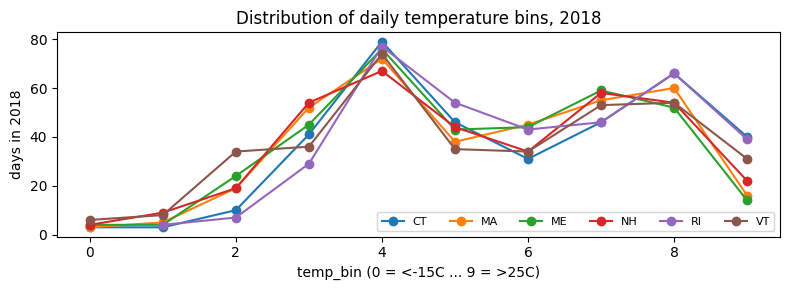

In [4]:
from opensynth.datasets.new_england.weather import build_temp_bin_table

temp_table = build_temp_bin_table(str(DATA_DIR))
print(temp_table.head())

fig, ax = plt.subplots(figsize=(8, 3))
for state in config.NE_STATES:
    counts = (
        temp_table.filter(pl.col("state") == state)
        .group_by("temp_bin")
        .len()
        .sort("temp_bin")
    )
    ax.plot(counts["temp_bin"], counts["len"], marker="o", label=state)
ax.set_xlabel("temp_bin (0 = <-15C ... 9 = >25C)")
ax.set_ylabel("days in 2018")
ax.legend(ncol=6, fontsize=8)
ax.set_title("Distribution of daily temperature bins, 2018")
plt.tight_layout()

## EULP timeseries and the timestamp convention

EULP timestamps are **period-ending in fixed EST** (first stamp of the year is
`2018-01-01 00:15`, last is `2019-01-01 00:00`). `melt_building` shifts them 15 minutes to
period-beginning so each calendar day owns exactly its 96 intervals — get this wrong and every
day steals its first reading from the previous day.

shape: (3, 3)
┌──────────┬─────────────────────┬───────┐
│ ID       ┆ DateTime            ┆ kwh   │
│ ---      ┆ ---                 ┆ ---   │
│ str      ┆ datetime[μs]        ┆ f64   │
╞══════════╪═════════════════════╪═══════╡
│ CT_36388 ┆ 2018-01-01 00:00:00 ┆ 3.253 │
│ CT_36388 ┆ 2018-01-01 00:15:00 ┆ 3.413 │
│ CT_36388 ┆ 2018-01-01 00:30:00 ┆ 3.314 │
└──────────┴─────────────────────┴───────┘
365 days, all with 96 readings


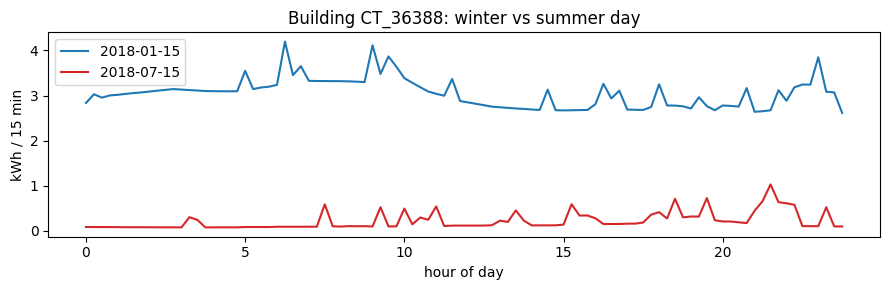

In [5]:
from opensynth.datasets.new_england.preprocess_ne import melt_building

row = manifest.row(0, named=True)
path = RAW / "eulp" / f"{row['state']}_{row['bldg_id']}-0.parquet"
df_long = melt_building(path, f"{row['state']}_{row['bldg_id']}")
print(df_long.head(3))

per_day = df_long.group_by(pl.col("DateTime").dt.date().alias("date")).len()
assert per_day["len"].unique().to_list() == [96]
print(f"{per_day.height} days, all with 96 readings")

fig, ax = plt.subplots(figsize=(9, 3))
for day, color in [("2018-01-15", "tab:blue"), ("2018-07-15", "tab:red")]:
    d = df_long.filter(
        pl.col("DateTime").dt.date() == pl.lit(day).str.to_date()
    )
    ax.plot(np.arange(96) / 4, d["kwh"], color=color, label=day)
ax.set_xlabel("hour of day")
ax.set_ylabel("kWh / 15 min")
ax.set_title(f"Building {row['state']}_{row['bldg_id']}: winter vs summer day")
ax.legend()
plt.tight_layout()

## Preprocessed splits

`preprocess-ne-data` melts the corpus per state (the full long table is ~63M rows, too large
for one in-memory pass), joins the integer conditioning labels and daily temp bins, applies
DER augmentation, and packs one row per home-day using the LCL pipeline functions. The split
is 75/25 **by building**, so no home leaks across splits.

In [6]:
for split in ["train", "holdout"]:
    lf = pl.scan_csv(PROCESSED / split / "data.csv")
    n = lf.select(pl.len()).collect().item()
    homes = lf.select(pl.col("ID").n_unique()).collect().item()
    print(f"{split}: {n:,} home-days from {homes} buildings")

label_ranges = (
    pl.scan_csv(PROCESSED / "train/data.csv")
    .select(
        [pl.col(c).min().alias(f"{c}_min") for c in config.FEATURE_COLS]
        + [pl.col(c).max().alias(f"{c}_max") for c in config.FEATURE_COLS]
    )
    .collect()
)
print(label_ranges)
stats = pl.read_csv(PROCESSED / "train/mean_std.csv")
print("Training standardisation stats:", stats.to_dicts()[0])

train: 492,750 home-days from 1350 buildings
holdout: 164,250 home-days from 450 buildings


shape: (1, 16)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ state_min ┆ archetype ┆ heating_f ┆ has_ev_mi ┆ … ┆ has_pv_ma ┆ month_max ┆ dayofweek ┆ temp_bin │
│ ---       ┆ _min      ┆ uel_min   ┆ n         ┆   ┆ x         ┆ ---       ┆ _max      ┆ _max     │
│ i64       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ i64       ┆ ---       ┆ ---      │
│           ┆ i64       ┆ i64       ┆ i64       ┆   ┆ i64       ┆           ┆ i64       ┆ i64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 0         ┆ 0         ┆ 0         ┆ 0         ┆ … ┆ 1         ┆ 12        ┆ 6         ┆ 9        │
└───────────┴───────────┴───────────┴───────────┴───┴───────────┴───────────┴───────────┴──────────┘
Training standardisation stats: {'mean': 0.2089519031589047, 'stdev': 0.31872093211730373}


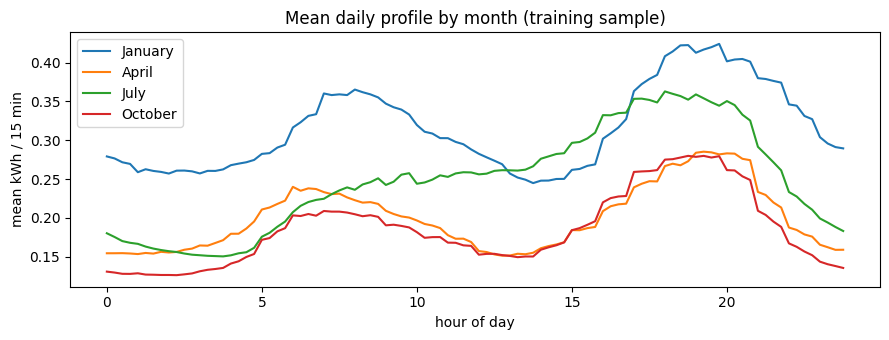

In [7]:
import ast

sample = (
    pl.scan_csv(PROCESSED / "train/data.csv")
    .select(["month", "kwh"])
    .filter(pl.col("month").is_in([1, 4, 7, 10]))
    .head(40_000)
    .collect()
)
kwh = np.array([ast.literal_eval(s) for s in sample["kwh"]])
assert kwh.shape[1] == 96

fig, ax = plt.subplots(figsize=(9, 3.5))
for month, label in [(1, "January"), (4, "April"), (7, "July"), (10, "October")]:
    mask = (sample["month"] == month).to_numpy()
    ax.plot(np.arange(96) / 4, kwh[mask].mean(axis=0), label=label)
ax.set_xlabel("hour of day")
ax.set_ylabel("mean kWh / 15 min")
ax.set_title("Mean daily profile by month (training sample)")
ax.legend()
plt.tight_layout()

## Caveats

- **PV / net load**: `has_pv` homes (assigned from RECS state shares) have PVWatts-model
  generation netted out, so their readings can go **negative** during export. Shapes come from
  Open-Meteo ERA5 for actual weather-year 2018 (the original PVWatts API is unreachable —
  nrel.gov lost its .gov DNS delegation), cross-checked against the PVGIS-NSRDB 2005–2015
  climatology: profile r ≈ 0.98, annual energy within 7–9 % (single-year weather + ERA5
  bias). See `scripts/fetch_pv_shapes.py`.
- **EV**: RECS 2020 EV-charging shares are 0.6–1.7 %, giving only ~13 EV homes in the training
  mix. v1 stays RECS-honest; a documented oversample is the open alternative (the label is a
  generation-time input, so the training mix need not match the population).
- `outliers.csv` holds synthetic noise profiles (the LCL `create_outliers` convention),
  appended during training to harden the VAE.